# Part-3 — Multimodal Price Prediction
### Contents
- A. Setup & data
- B. Image pipeline (Keras Sequence + augmentation)
- C. Model definition (M2)
- D. Training — two-phase (frozen → fine-tune)
- E. Evaluation & ablation table (M1 vs M2)
- F. Error analysis

In [ ]:
import os
from google.colab import drive

# connecting Google Drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/OzU/DeepLearning/Project'

# coping images.zip into local SSD Colab and unzipping
if not os.path.exists('/content/Images'):
    print('coping...')
    !cp "{DRIVE_DIR}/images.zip" /content/images.zip
    print('Unzipping...')
    !unzip -q /content/images.zip -d /content/
    !rm /content/images.zip
    print(f'Done. Images: {len(os.listdir("/content/Images"))}')
else:
    print('Images already unzipped.')

BASE_DIR = '/content'
DATA_DIR = DRIVE_DIR
IMAGES_DIR = '/content/Images'
CLEAN_CSV = os.path.join(DATA_DIR, 'data_clean.csv')
CKPT_DIR = os.path.join(DRIVE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('CKPT_DIR:', CKPT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
coping...
Unzipping...
Done. Images: 24053
BASE_DIR: /content
DATA_DIR: /content/drive/MyDrive/OzU/DeepLearning/Project
CKPT_DIR: /content/drive/MyDrive/OzU/DeepLearning/Project/checkpoints


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## A. Data Loading

In [ ]:
df = pd.read_csv(CLEAN_CSV, encoding='utf-8-sig')
df['photo_rel'] = df['photo_rel'].str.replace(
    'Data/Istanbul/Images', 'Images', regex=False)

ILCE_COLS = [c for c in df.columns if c.startswith('ilce_')]
TAB_FEATURES = ['area_scaled', 'rooms_scaled'] + ILCE_COLS
TARGET = 'log_price'
IMG_SIZE = 224

df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val = df[df['split'] == 'val'].reset_index(drop=True)
df_test = df[df['split'] == 'test'].reset_index(drop=True)

print(f'Sizes: Train: {len(df_train):,},  Val: {len(df_val):,},  Test: {len(df_test):,}')
print(f'Tabular features: {len(TAB_FEATURES)}')

Sizes: Train: 15,780,  Val: 3,381,  Test: 3,382
Tabular features: 41


In [ ]:
# check whether the img path is correct
sample = os.path.join(BASE_DIR, df['photo_rel'].iloc[0])
print("path:", sample)
print("exists:", os.path.exists(sample))

path: /content/Images/1318389113/photo_1.jpg
exists: True


---
## B. Image Pipeline — Keras Sequence

In [ ]:
class ListingSequence(keras.utils.Sequence):
    """
    Keras Sequence (generator) that yields batches of
    ({'image_input': img_batch, 'tabular_input': tab_batch}, y_batch).

    Images are loaded as [0, 255] uint8 RGB and preprocessed
    with EfficientNet's built-in preprocess_input.
    Data augmentation is applied only when augment=True (train set).
    """

    def __init__(self, df: pd.DataFrame, tab_cols: list,
                 base_dir: str, batch_size: int = 32, augment: bool = False):
        self.df         = df.reset_index(drop=True)
        self.tab_cols   = tab_cols
        self.base_dir   = base_dir
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(self.df))

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.augment:
            np.random.shuffle(self.indices)

    def _load_image(self, rel_path: str) -> np.ndarray:
        path = os.path.join(self.base_dir, rel_path.replace('/', os.sep))
        try:
            img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            return np.array(img, dtype=np.float32)   # [0, 255]
        except Exception:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

    def _augment(self, img: np.ndarray) -> np.ndarray:
        """Simple numpy augmentation (no extra dependency)."""
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = img[:, ::-1, :]
        # Random brightness +-20%
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255)
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]

        imgs = []
        for _, row in batch.iterrows():
            img = self._load_image(str(row['photo_rel']))
            if self.augment:
                img = self._augment(img)
            imgs.append(img)

        img_batch = preprocess_input(np.stack(imgs))   # EfficientNet normalization
        tab_batch = batch[self.tab_cols].values.astype(np.float32)
        y_batch = batch[TARGET].values.astype(np.float32)

        return {'image_input': img_batch, 'tabular_input': tab_batch}, y_batch


BATCH_SIZE = 32

train_seq = ListingSequence(df_train, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=True)
val_seq = ListingSequence(df_val, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=False)
test_seq = ListingSequence(df_test, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=False)

print(f'Train batches: {len(train_seq)} | Val: {len(val_seq)} | Test: {len(test_seq)}')

# Sanity check
batch_inputs, y_check = train_seq[0]
x_check = batch_inputs['image_input']
tab_check = batch_inputs['tabular_input']
print(f'Image batch: {x_check.shape}   dtype={x_check.dtype}')
print(f'Tabular batch: {tab_check.shape}')
print(f'Label batch: {y_check.shape}')

Train batches: 494 | Val: 106 | Test: 106
Image batch: (32, 224, 224, 3)   dtype=float32
Tabular batch: (32, 41)
Label batch: (32,)


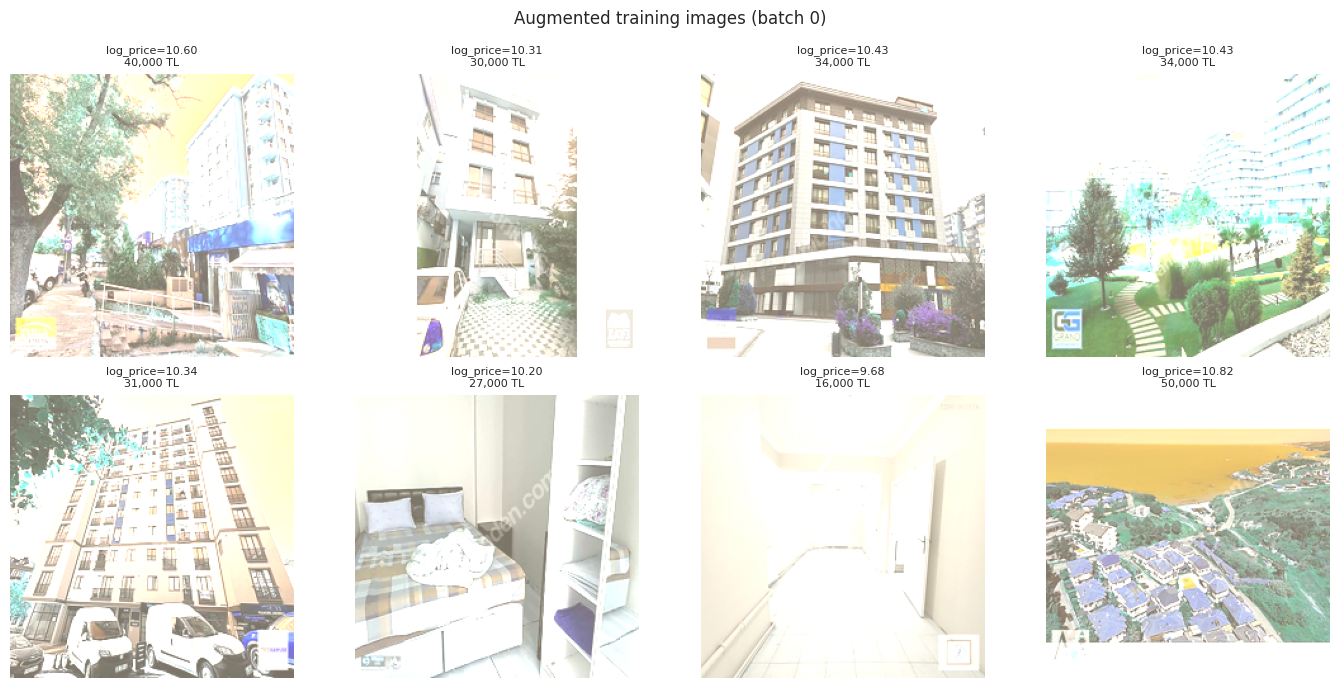

In [ ]:
# Show sample augmented images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    if i >= len(y_check): break
    # Reverse EfficientNet preprocess for display
    img_display = np.clip(x_check[i] + [103.939, 116.779, 123.68], 0, 255).astype(np.uint8)
    img_display = img_display[:, :, ::-1]   # BGR → RGB
    ax.imshow(img_display)
    ax.set_title(f'log_price={y_check[i]:.2f}\n{np.expm1(y_check[i]):,.0f} TL', fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented training images (batch 0)', fontsize=12)
plt.tight_layout()
plt.show()

---
## C. Late Fusion Model — Keras Functional API

```
image_input(224,224,3)         tabular_input(41,)
       │                               │
EfficientNetB0 (pretrained)      Dense(128) → BN → ReLU → Dropout
GlobalAvgPool2D → [1280]              │
Dense(256) → BN → ReLU          Dense(64) → BN → ReLU
       │                               │
       └──────── Concatenate ──────────┘
                     │  [320]
             Dense(256) → BN → ReLU → Dropout
                     │
                  Dense(1)   ← log_price
```

In [ ]:
def build_late_fusion(n_tab, dropout=0.3, lr=1e-3,
                      trainable_backbone=False):
    """
    M2: Late Fusion - EfficientNetB0 + MLP.
    Loss: Huber(delta=1.0) - more robust to price outliers than MSE.
    """
    # --- Image branch ---
    image_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    backbone = EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=image_input
    )
    backbone.trainable = trainable_backbone

    x_img = backbone.output
    x_img = layers.GlobalAveragePooling2D(name='gap')(x_img)
    x_img = layers.Dropout(dropout, name='drop_img')(x_img)
    x_img = layers.Dense(256, use_bias=False, name='img_proj')(x_img)
    x_img = layers.BatchNormalization(name='img_bn')(x_img)
    x_img = layers.Activation('relu', name='img_relu')(x_img)

    # --- Tabular branch ---
    tab_input = keras.Input(shape=(n_tab,), name='tabular_input')
    x_tab = layers.Dense(128, use_bias=False, name='tab_d1')(tab_input)
    x_tab = layers.BatchNormalization(name='tab_bn1')(x_tab)
    x_tab = layers.Activation('relu', name='tab_relu1')(x_tab)
    x_tab = layers.Dropout(dropout, name='tab_drop')(x_tab)
    x_tab = layers.Dense(64, use_bias=False, name='tab_d2')(x_tab)
    x_tab = layers.BatchNormalization(name='tab_bn2')(x_tab)
    x_tab = layers.Activation('relu', name='tab_relu2')(x_tab)

    # --- Late fusion ---
    fused = layers.Concatenate(name='fusion')([x_img, x_tab])  # 256 + 64 = 320
    x = layers.Dense(256, use_bias=False, name='fusion_d')(fused)
    x = layers.BatchNormalization(name='fusion_bn')(x)
    x = layers.Activation('relu', name='fusion_relu')(x)
    x = layers.Dropout(dropout, name='fusion_drop')(x)
    output = layers.Dense(1, name='output')(x)

    model = keras.Model(
        inputs=[image_input, tab_input],
        outputs=output,
        name='LateFusion_M2'
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
    )
    return model


m2 = build_late_fusion(n_tab=len(TAB_FEATURES), trainable_backbone=False)
m2.summary()

trainable = sum(np.prod(w.shape) for w in m2.trainable_weights)
frozen = sum(np.prod(w.shape) for w in m2.non_trainable_weights)
print(f'\nTrainable params : {trainable:,}')
print(f'Frozen params    : {frozen:,}')

Model: "LateFusion_M2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,475,684 (17.07 MB)

 Trainable params: 424,705 (1.62 MB)

 Non-trainable params: 4,050,979 (15.45 MB)


Trainable params : 424,705
Frozen params    : 4,050,979.0


---
## D. Training — Two-Phase

**Phase 1** (backbone frozen): обучаем только голову — быстро, стабильно, не портим веса ImageNet.  
**Phase 2** (backbone разморожен): тонкая настройка всей сети с маленьким LR + CosineDecay.

In [ ]:
CKPT_PATH = os.path.join(CKPT_DIR, 'fusion_m2_best.keras')
EPOCHS_FROZEN = 15
EPOCHS_FINETUNE = 15
PATIENCE = 10

def make_callbacks(ckpt_path, patience):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_loss',
            save_best_only=True, verbose=0
        ),
    ]

# Phase 1: frozen backbone
print(f'Phase 1: frozen backbone  (max {EPOCHS_FROZEN} epochs)')

hist1 = m2.fit(
    train_seq, validation_data=val_seq,
    epochs=EPOCHS_FROZEN,
    callbacks=make_callbacks(CKPT_PATH, PATIENCE),
    verbose=1
)
n_frozen_epochs = len(hist1.history['loss'])

Phase 1: frozen backbone  (max 15 epochs)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 3.2202 - mae: 3.6635

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


494/494 ━━━━━━━━━━━━━━━━━━━━ 186s 322ms/step - loss: 1.3732 - mae: 1.7827 - val_loss: 0.1232 - val_mae: 0.3940 - learning_rate: 0.0010
Epoch 2/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 114s 230ms/step - loss: 0.4342 - mae: 0.8064 - val_loss: 0.1277 - val_mae: 0.4048 - learning_rate: 0.0010
Epoch 3/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 119s 242ms/step - loss: 0.3566 - mae: 0.7173 - val_loss: 0.1222 - val_mae: 0.3890 - learning_rate: 0.0010
Epoch 4/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 118s 239ms/step - loss: 0.3073 - mae: 0.6548 - val_loss: 0.1148 - val_mae: 0.3865 - learning_rate: 0.0010
Epoch 5/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 121s 245ms/step - loss: 0.2776 - mae: 0.6192 - val_loss: 0.0849 - val_mae: 0.3292 - learning_rate: 0.0010
Epoch 6/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 116s 236ms/step - loss: 0.2556 - mae: 0.5908 - val_loss: 0.0711 - val_mae: 0.2985 - learning_rate: 0.0010
Epoch 7/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 116s 235ms/step - loss: 0.2470 - mae: 0.5782 - val_loss: 0.0674 - val_mae: 0.2950 - learning_ra

In [ ]:
# Phase 2: unfreeze & fine-tune
print(f'Phase 2: full fine-tune  (max {EPOCHS_FINETUNE} epochs)')

for layer in m2.layers:
    if 'efficientnet' in layer.name.lower():
        layer.trainable = True

total_steps = EPOCHS_FINETUNE * len(train_seq)
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5, decay_steps=total_steps
)
m2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.Huber(delta=1.0),
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
)

hist2 = m2.fit(
    train_seq, validation_data=val_seq,
    epochs=EPOCHS_FINETUNE,
    callbacks=make_callbacks(CKPT_PATH, PATIENCE),
    verbose=1
)

Phase 2: full fine-tune  (max 15 epochs)
Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 174s 294ms/step - loss: 0.1635 - mae: 0.4623 - val_loss: 0.0390 - val_mae: 0.2096 - learning_rate: 4.9454e-05
Epoch 2/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 118s 238ms/step - loss: 0.1651 - mae: 0.4630 - val_loss: 0.0384 - val_mae: 0.2083 - learning_rate: 4.7839e-05
Epoch 3/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 114s 230ms/step - loss: 0.1583 - mae: 0.4526 - val_loss: 0.0370 - val_mae: 0.2050 - learning_rate: 4.5225e-05
Epoch 4/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 120s 242ms/step - loss: 0.1646 - mae: 0.4634 - val_loss: 0.0377 - val_mae: 0.2074 - learning_rate: 4.1728e-05
Epoch 5/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 120s 243ms/step - loss: 0.1607 - mae: 0.4565 - val_loss: 0.0371 - val_mae: 0.2058 - learning_rate: 3.7500e-05
Epoch 6/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 139s 237ms/step - loss: 0.1617 - mae: 0.4570 - val_loss: 0.0381 - val_mae: 0.2108 - learning_rate: 3.2725e-05
Epoch 7/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 117s 237ms/step - l

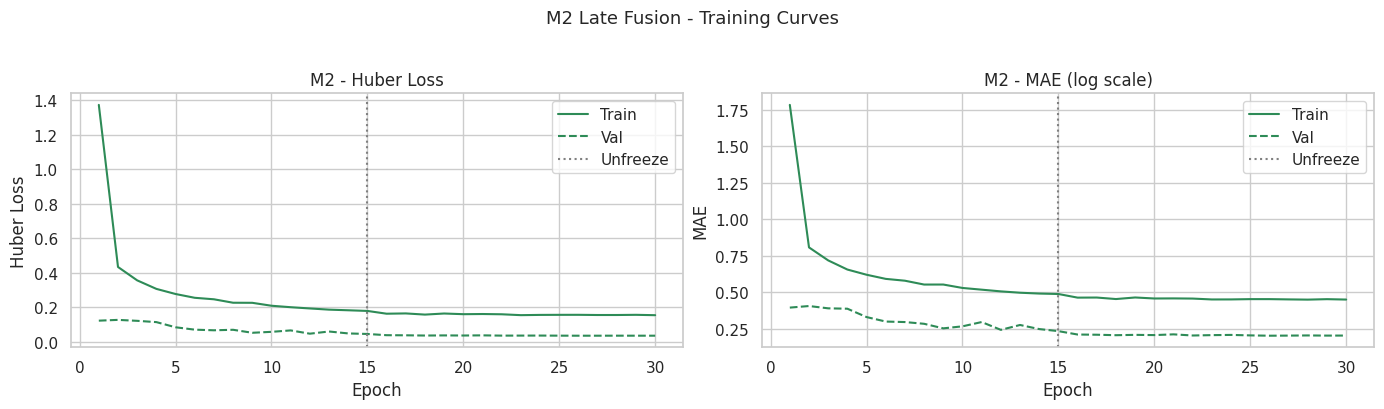

In [ ]:
# Learning curves (both phases)
all_loss = hist1.history['loss'] + hist2.history['loss']
all_val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
all_mae = hist1.history['mae'] + hist2.history['mae']
all_val_mae = hist1.history['val_mae'] + hist2.history['val_mae']
epochs_range = range(1, len(all_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_range, all_loss, label='Train', color='seagreen')
axes[0].plot(epochs_range, all_val_loss, label='Val', color='seagreen', ls='--')
axes[0].axvline(n_frozen_epochs, color='grey', ls=':', lw=1.5, label='Unfreeze')
axes[0].set_title('M2 - Huber Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()

axes[1].plot(epochs_range, all_mae, label='Train', color='seagreen')
axes[1].plot(epochs_range, all_val_mae, label='Val', color='seagreen', ls='--')
axes[1].axvline(n_frozen_epochs, color='grey', ls=':', lw=1.5, label='Unfreeze')
axes[1].set_title('M2 - MAE (log scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('M2 Late Fusion - Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm2_learning_curves.png'), bbox_inches='tight')
plt.show()

---
## E. Evaluation & Comparison M1 vs M2

In [ ]:
CKPT_PATH = os.path.join(CKPT_DIR, 'fusion_m2_best.keras')

In [ ]:
# Load best M2 checkpoint
m2 = keras.models.load_model(CKPT_PATH)

def predict_seq(model, seq):
    preds, targets = [], []
    for batch_inputs, y_batch in seq:
        p = model.predict(batch_inputs, verbose=0).flatten()
        preds.extend(p)
        targets.extend(y_batch)
    return np.array(preds), np.array(targets)


def compute_metrics(preds_log, targets_log):
    preds_tl   = np.expm1(preds_log)
    targets_tl = np.expm1(targets_log)
    return dict(
        MAE = mean_absolute_error(targets_tl, preds_tl),
        RMSE = np.sqrt(mean_squared_error(targets_tl, preds_tl)),
        MAPE = np.mean(np.abs((targets_tl - preds_tl) / targets_tl)) * 100,
        R2 = r2_score(targets_tl, preds_tl),
        preds_tl=preds_tl, targets_tl=targets_tl
    )


# M2 predictions
p_m2_log, t_log = predict_seq(m2, test_seq)
met_m2 = compute_metrics(p_m2_log, t_log)

print('M2 - Test Set Results')
print(f'MAE: {met_m2["MAE"]:>10,.0f} TL')
print(f'RMSE: {met_m2["RMSE"]:>10,.0f} TL')
print(f'MAPE: {met_m2["MAPE"]:>10.2f} %')
print(f'R²: {met_m2["R2"]:>10.4f}')

M2 - Test Set Results
MAE:      6,626 TL
RMSE:      8,654 TL
MAPE:      21.42 %
R²:     0.4614


In [ ]:
# Load M1 metrics
m1_df = pd.read_csv(os.path.join(DATA_DIR, 'm1_metrics.csv'), index_col='Split')
m1_test = m1_df.loc['Test']

# Comparison table
comparison = pd.DataFrame({
    'Model': ['M1 - Tabular MLP (baseline)', 'M2 - Late Fusion (proposed)'],
    'Input': ['Tabular only', 'Image + Tabular'],
    'MAE (TL)': [m1_test['MAE (TL)'], met_m2['MAE']],
    'RMSE (TL)': [m1_test['RMSE (TL)'], met_m2['RMSE']],
    'MAPE (%)': [m1_test['MAPE (%)'], met_m2['MAPE']],
    'R²': [m1_test['R²'], met_m2['R2']],
}).set_index('Model')

comparison = comparison.round({'MAE (TL)': 0, 'RMSE (TL)': 0,
                                'MAPE (%)': 2, 'R²': 4})
display(comparison)
comparison.to_csv(os.path.join(DATA_DIR, 'model_comparison_m1_m2.csv'))
print('Saved to model_comparison_m1_m2.csv')

,Input,MAE (TL),RMSE (TL),MAPE (%),R²
Model,,,,,
M1 - Tabular MLP (baseline),Tabular only,7439.0,9571.0,24.10,0.3413
M2 - Late Fusion (proposed),Image + Tabular,6626.0,8654.0,21.42,0.4614


Saved to model_comparison_m1_m2.csv


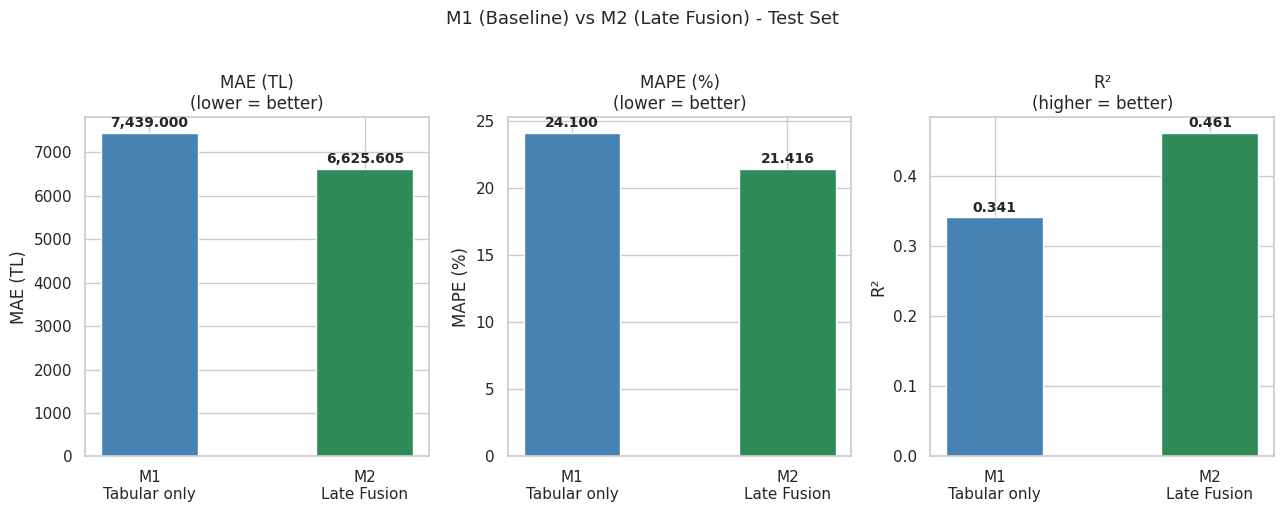

In [ ]:
# Bar chart: M1 vs M2
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
labels = ['M1\nTabular only', 'M2\nLate Fusion']
colors = ['steelblue', 'seagreen']

metrics_plot = [
    ([m1_test['MAE (TL)'], met_m2['MAE']], 'MAE (TL)', 'lower = better'),
    ([m1_test['MAPE (%)'], met_m2['MAPE']], 'MAPE (%)', 'lower = better'),
    ([m1_test['R²'], met_m2['R2']], 'R²', 'higher = better'),
]
for ax, (vals, ylabel, note) in zip(axes, metrics_plot):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.45)
    ax.set_title(f'{ylabel}\n({note})')
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:,.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('M1 (Baseline) vs M2 (Late Fusion) - Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison.png'), bbox_inches='tight')
plt.show()

---
## E2. Architecture Comparison — 3 Configurations

To justify the architectural and training choices we train two additional variants
and compare all three on the **test set**:

| Config | Backbone | Phase 2 fine-tune | ~Time |
|--------|----------|-------------------|-------|
| **A** | MobileNetV2 (ImageNet) | ✓ CosineDecay | ~45 min |
| **B** | EfficientNetB0 (ImageNet) | ✗ frozen only | ~28 min |
| **C ★** | EfficientNetB0 (ImageNet) | ✓ CosineDecay | already done |

The best-performing configuration is then used as the final M2 in the M1 vs M2 comparison.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess

class ListingSequenceMob(ListingSequence):
    """Same pipeline as ListingSequence but uses MobileNetV2 preprocess_input ([-1, 1])."""
    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]
        imgs = []
        for _, row in batch.iterrows():
            img = self._load_image(str(row['photo_rel']))
            if self.augment:
                img = self._augment(img)
            imgs.append(img)
        img_batch = mob_preprocess(np.stack(imgs))
        tab_batch = batch[self.tab_cols].values.astype(np.float32)
        y_batch = batch[TARGET].values.astype(np.float32)
        return {'image_input': img_batch, 'tabular_input': tab_batch}, y_batch


def build_mobilenet_fusion(n_tab, dropout=0.3, lr=1e-3, trainable_backbone=False):
    """Late Fusion with MobileNetV2 backbone — identical head to build_late_fusion."""
    image_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    backbone = MobileNetV2(include_top=False, weights='imagenet',
                              input_tensor=image_input)
    backbone.trainable = trainable_backbone

    x_img = backbone.output
    x_img = layers.GlobalAveragePooling2D(name='gap')(x_img)
    x_img = layers.Dropout(dropout, name='drop_img')(x_img)
    x_img = layers.Dense(256, use_bias=False, name='img_proj')(x_img)
    x_img = layers.BatchNormalization(name='img_bn')(x_img)
    x_img = layers.Activation('relu', name='img_relu')(x_img)

    tab_input = keras.Input(shape=(n_tab,), name='tabular_input')
    x_tab = layers.Dense(128, use_bias=False, name='tab_d1')(tab_input)
    x_tab = layers.BatchNormalization(name='tab_bn1')(x_tab)
    x_tab = layers.Activation('relu', name='tab_relu1')(x_tab)
    x_tab = layers.Dropout(dropout, name='tab_drop')(x_tab)
    x_tab = layers.Dense(64, use_bias=False, name='tab_d2')(x_tab)
    x_tab = layers.BatchNormalization(name='tab_bn2')(x_tab)
    x_tab = layers.Activation('relu', name='tab_relu2')(x_tab)

    fused  = layers.Concatenate(name='fusion')([x_img, x_tab])
    x = layers.Dense(256, use_bias=False, name='fusion_d')(fused)
    x = layers.BatchNormalization(name='fusion_bn')(x)
    x = layers.Activation('relu', name='fusion_relu')(x)
    x = layers.Dropout(dropout, name='fusion_drop')(x)
    output = layers.Dense(1, name='output')(x)

    model = keras.Model(inputs=[image_input, tab_input], outputs=output,
                        name='LateFusion_MobileNetV2')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=keras.losses.Huber(delta=1.0),
                  metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model


# MobileNetV2 sequences (different preprocess_input!)
train_seq_mob = ListingSequenceMob(df_train, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=True)
val_seq_mob = ListingSequenceMob(df_val, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=False)
test_seq_mob = ListingSequenceMob(df_test, TAB_FEATURES, BASE_DIR, BATCH_SIZE, augment=False)

print('MobileNetV2 sequences ready.')
print(f'Train batches: {len(train_seq_mob)} | Val: {len(val_seq_mob)} | Test: {len(test_seq_mob)}')

MobileNetV2 sequences ready.
Train batches: 494 | Val: 106 | Test: 106


In [ ]:
# CONFIG A — MobileNetV2, Phase 1 (frozen) + Phase 2 (fine-tune)
CKPT_A = os.path.join(CKPT_DIR, 'fusion_m2a_mobilenet.keras')
EPOCHS_A1 = 15
EPOCHS_A2 = 15

print('Config A — MobileNetV2  |  Phase 1 (frozen)')
print('-' * 55)
m2_a = build_mobilenet_fusion(n_tab=len(TAB_FEATURES), trainable_backbone=False)

hist_a1 = m2_a.fit(
    train_seq_mob, validation_data=val_seq_mob,
    epochs=EPOCHS_A1,
    callbacks=make_callbacks(CKPT_A, PATIENCE),
    verbose=1
)

print('\n')
print('Config A — MobileNetV2  |  Phase 2 (fine-tune)')
print('-' * 55)
m2_a.trainable = True                              # unfreeze all layers
total_steps_a  = EPOCHS_A2 * len(train_seq_mob)
lr_a = keras.optimizers.schedules.CosineDecay(5e-5, total_steps_a)
m2_a.compile(optimizer=keras.optimizers.Adam(lr_a),
             loss=keras.losses.Huber(delta=1.0),
             metrics=[keras.metrics.MeanAbsoluteError(name='mae')])

hist_a2 = m2_a.fit(
    train_seq_mob, validation_data=val_seq_mob,
    epochs=EPOCHS_A2,
    callbacks=make_callbacks(CKPT_A, PATIENCE),
    verbose=1
)

m2_a = keras.models.load_model(CKPT_A)
p_a, _ = predict_seq(m2_a, test_seq_mob)
met_a = compute_metrics(p_a, t_log)
print(f'\nConfig A result → MAE: {met_a["MAE"]:,.0f} TL  MAPE: {met_a["MAPE"]:.2f}%  R²: {met_a["R2"]:.4f}')

Config A — MobileNetV2  |  Phase 1 (frozen)
-------------------------------------------------------


/tmp/ipykernel_3216/3394844213.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(include_top=False, weights='imagenet',


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 2.6828 - mae: 3.1213

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


494/494 ━━━━━━━━━━━━━━━━━━━━ 163s 288ms/step - loss: 1.1874 - mae: 1.5951 - val_loss: 0.2815 - val_mae: 0.6287 - learning_rate: 0.0010
Epoch 2/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 118s 239ms/step - loss: 0.4341 - mae: 0.8072 - val_loss: 0.1192 - val_mae: 0.3833 - learning_rate: 0.0010
Epoch 3/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 115s 233ms/step - loss: 0.3517 - mae: 0.7104 - val_loss: 0.0859 - val_mae: 0.3197 - learning_rate: 0.0010
Epoch 4/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 115s 233ms/step - loss: 0.3059 - mae: 0.6533 - val_loss: 0.0837 - val_mae: 0.3273 - learning_rate: 0.0010
Epoch 5/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 116s 235ms/step - loss: 0.2863 - mae: 0.6309 - val_loss: 0.0702 - val_mae: 0.2889 - learning_rate: 0.0010
Epoch 6/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 118s 239ms/step - loss: 0.2643 - mae: 0.6020 - val_loss: 0.0773 - val_mae: 0.3025 - learning_rate: 0.0010
Epoch 7/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 115s 233ms/step - loss: 0.2433 - mae: 0.5734 - val_loss: 0.0726 - val_mae: 0.3010 - learning_ra

In [ ]:
# CONFIG B — EfficientNetB0, Phase 1 only (no fine-tune)
CKPT_B = os.path.join(CKPT_DIR, 'fusion_m2b_phase1only.keras')
EPOCHS_B = 15

print('Config B — EfficientNetB0  |  Phase 1 only (frozen)')
print('-' * 55)
m2_b = build_late_fusion(n_tab=len(TAB_FEATURES), trainable_backbone=False)

hist_b = m2_b.fit(
    train_seq, validation_data=val_seq,
    epochs=EPOCHS_B,
    callbacks=make_callbacks(CKPT_B, PATIENCE),
    verbose=1
)

m2_b = keras.models.load_model(CKPT_B)
p_b, _ = predict_seq(m2_b, test_seq)
met_b = compute_metrics(p_b, t_log)
print(f'\nConfig B result → MAE: {met_b["MAE"]:,.0f} TL  MAPE: {met_b["MAPE"]:.2f}%  R²: {met_b["R2"]:.4f}')

Config B — EfficientNetB0  |  Phase 1 only (frozen)
-------------------------------------------------------
Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 176s 298ms/step - loss: 1.3709 - mae: 1.7801 - val_loss: 0.2217 - val_mae: 0.5552 - learning_rate: 0.0010
Epoch 2/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 124s 252ms/step - loss: 0.4348 - mae: 0.8093 - val_loss: 0.1323 - val_mae: 0.4132 - learning_rate: 0.0010
Epoch 3/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 120s 243ms/step - loss: 0.3563 - mae: 0.7165 - val_loss: 0.0939 - val_mae: 0.3445 - learning_rate: 0.0010
Epoch 4/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 117s 236ms/step - loss: 0.3006 - mae: 0.6470 - val_loss: 0.0897 - val_mae: 0.3386 - learning_rate: 0.0010
Epoch 5/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 117s 236ms/step - loss: 0.2843 - mae: 0.6253 - val_loss: 0.0642 - val_mae: 0.2759 - learning_rate: 0.0010
Epoch 6/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 117s 237ms/step - loss: 0.2528 - mae: 0.5854 - val_loss: 0.0698 - val_mae: 0.2904 - learning_rate: 0.0010
Epoch 7/15
494/4

In [ ]:
CKPT_A = os.path.join(CKPT_DIR, 'fusion_m2a_mobilenet.keras')
m2_a = keras.models.load_model(CKPT_A)
p_a, _ = predict_seq(m2_a, test_seq_mob)
met_a = compute_metrics(p_a, t_log)

CKPT_B = os.path.join(CKPT_DIR, 'fusion_m2b_phase1only.keras')
m2_b = keras.models.load_model(CKPT_B)
p_b, _ = predict_seq(m2_b, test_seq)
met_b = compute_metrics(p_b, t_log)

3-Configuration Comparison — Test Set


,Backbone,Fine-tune,MAE (TL),MAPE (%),R²
Configuration,,,,,
A — MobileNetV2 (Ph1+Ph2),MobileNetV2,✓,6903,22.639999,0.4190
B — EfficientNetB0 (Ph1 only),EfficientNetB0,✗,7485,22.760000,0.2968
C — EfficientNetB0 (Ph1+Ph2) ★,EfficientNetB0,✓,6625,21.420000,0.4614



★ Best configuration: C — EfficientNetB0  (Ph1+Ph2)  ★
  MAE  = 6,626 TL
  MAPE = 21.42 %
  R²   = 0.4614

Saved → m2_config_comparison.csv


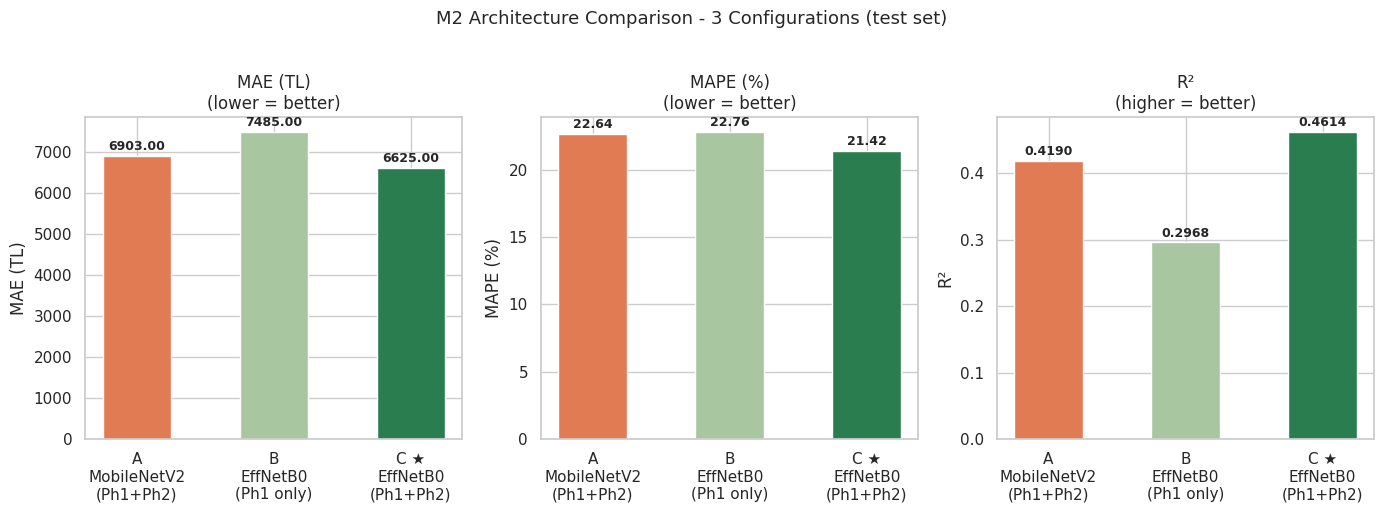

In [ ]:
# 3-way comparison + select best for final M1 vs M2 table
all_configs = [
    ('A — MobileNetV2  (Ph1+Ph2)',           'MobileNetV2',    '✓', met_a),
    ('B — EfficientNetB0  (Ph1 only)',        'EfficientNetB0', '✗', met_b),
    ('C — EfficientNetB0  (Ph1+Ph2)  ★',     'EfficientNetB0', '✓', met_m2),
]

comp3 = pd.DataFrame([{
    'Configuration': label,
    'Backbone':      backbone,
    'Fine-tune':     ft,
    'MAE (TL)':      int(m['MAE']),
    'MAPE (%)':      round(m['MAPE'], 2),
    'R²':            round(m['R2'], 4),
} for label, backbone, ft, m in all_configs]).set_index('Configuration')

print('3-Configuration Comparison — Test Set')
display(comp3)

# --- Identify best ---
best_row  = comp3['MAE (TL)'].idxmin()
best_met  = [met_a, met_b, met_m2][comp3['MAE (TL)'].values.argmin()]
print(f'\n★ Best configuration: {best_row}')
print(f'  MAE  = {best_met["MAE"]:,.0f} TL')
print(f'  MAPE = {best_met["MAPE"]:.2f} %')
print(f'  R²   = {best_met["R2"]:.4f}')

comp3.to_csv(os.path.join(DATA_DIR, 'm2_config_comparison.csv'))
print('\nSaved → m2_config_comparison.csv')

# --- Bar chart: all 3 configs ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
xlabels = ['A\nMobileNetV2\n(Ph1+Ph2)', 'B\nEffNetB0\n(Ph1 only)', 'C ★\nEffNetB0\n(Ph1+Ph2)']
colors3 = ['#e07b54', '#a8c6a0', '#2a7d4f']

for ax, (col, note) in zip(axes, [
    ('MAE (TL)',  'lower = better'),
    ('MAPE (%)', 'lower = better'),
    ('R²',       'higher = better'),
]):
    vals = comp3[col].tolist()
    bars = ax.bar(xlabels, vals, color=colors3, edgecolor='white', width=0.5)
    ax.set_title(f'{col}\n({note})'); ax.set_ylabel(col)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.2f}' if col != 'R²' else f'{v:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('M2 Architecture Comparison - 3 Configurations (test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm2_config_comparison.png'), bbox_inches='tight')
plt.show()

---
## F. Error Analysis

### F1. Predicted vs Actual — M1 vs M2

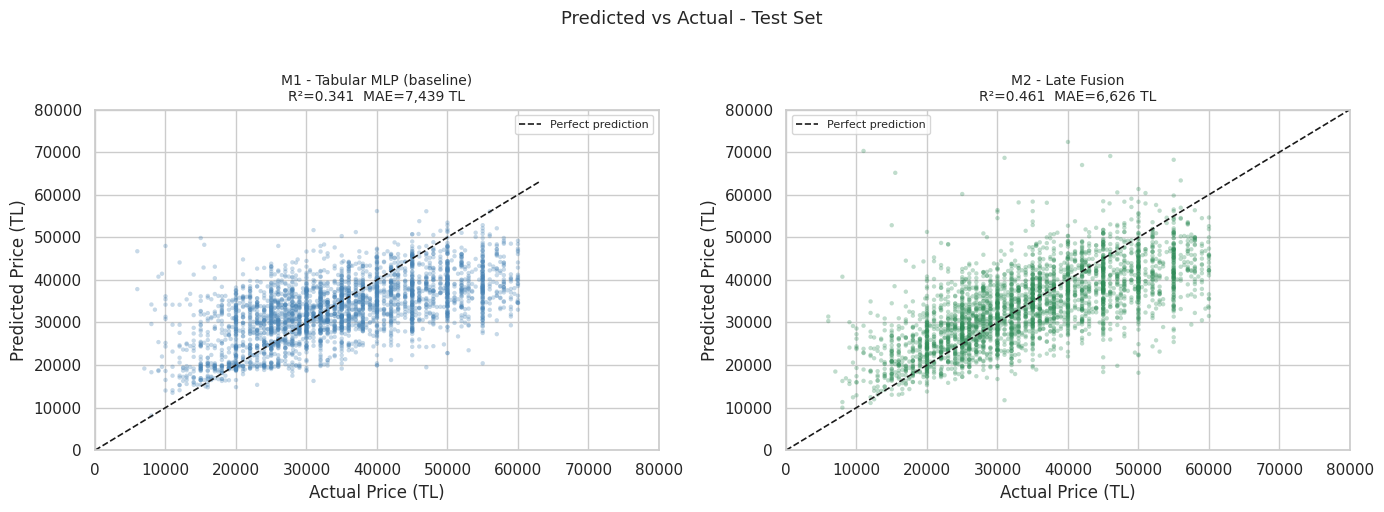

In [ ]:
# M1 predictions
m1_model = keras.models.load_model(os.path.join(CKPT_DIR, 'mlp_m1_best.keras'))
X_test_tab = df_test[TAB_FEATURES].values.astype(np.float32)
p_m1_tl = np.expm1(m1_model.predict(X_test_tab, verbose=0).flatten())
t_tl = met_m2['targets_tl']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (preds, name, color) in zip(axes, [
    (p_m1_tl, 'M1 - Tabular MLP (baseline)', 'steelblue'),
    (met_m2['preds_tl'], 'M2 - Late Fusion', 'seagreen'),
]):
    mx = max(t_tl.max(), preds.max()) * 1.05
    ax.scatter(t_tl, preds, alpha=0.3, s=10, color=color, edgecolors='none')
    ax.plot([0, mx], [0, mx], 'k--', lw=1.2, label='Perfect prediction')
    r2 = r2_score(t_tl, preds)
    mae = mean_absolute_error(t_tl, preds)
    ax.set_title(f'{name}\nR²={r2:.3f}  MAE={mae:,.0f} TL', fontsize=10)
    ax.set_xlabel('Actual Price (TL)')
    ax.set_ylabel('Predicted Price (TL)')
    ax.set_xlim(0, 80_000); ax.set_ylim(0, 80_000) #mx вместо 80
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual - Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'pred_vs_actual_m1_m2.png'), bbox_inches='tight')
plt.show()

### F2. Residuals — M2

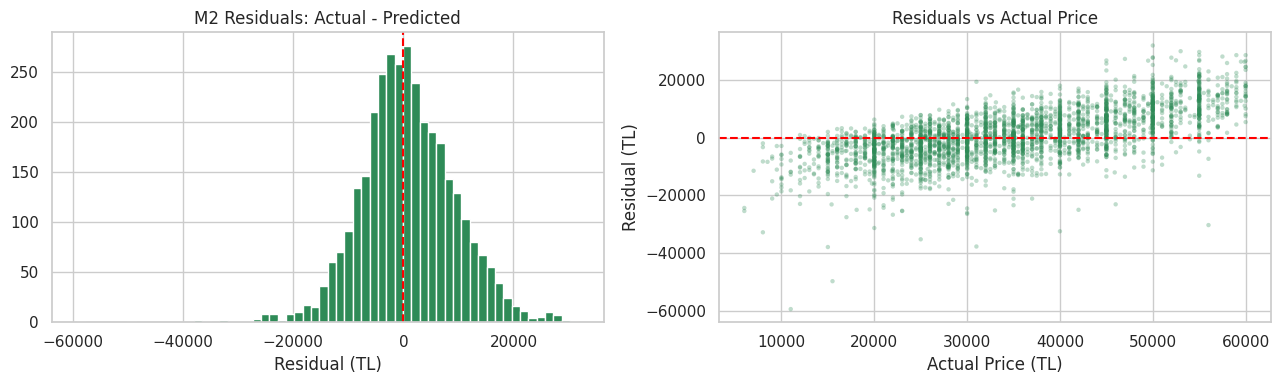

Mean: 820 TL  |  Std: 8,616 TL


In [ ]:
residuals = t_tl - met_m2['preds_tl']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=60, color='seagreen', edgecolor='white')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('M2 Residuals: Actual - Predicted')
axes[0].set_xlabel('Residual (TL)')

axes[1].scatter(t_tl, residuals, alpha=0.3, s=10, color='seagreen', edgecolors='none')
axes[1].axhline(0, color='red', ls='--')
axes[1].set_xlabel('Actual Price (TL)')
axes[1].set_ylabel('Residual (TL)')
axes[1].set_title('Residuals vs Actual Price')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'm2_residuals.png'), bbox_inches='tight')
plt.show()
print(f'Mean: {residuals.mean():,.0f} TL  |  Std: {residuals.std():,.0f} TL')

### F3. Best & Worst predictions — M2

In [ ]:
df_err = df_test[['photo_rel', 'ilce', 'Rooms', 'NetArea', 'Price']].copy()
df_err['pred'] = met_m2['preds_tl']
df_err['abs_err'] = np.abs(df_err['Price'] - df_err['pred'])
df_err['pct_err'] = df_err['abs_err'] / df_err['Price'] * 100

for title, subset in [('Worst 6 predictions', df_err.nlargest(6, 'abs_err')),
                       ('Best 6 predictions',  df_err.nsmallest(6, 'abs_err'))]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, (_, row) in zip(axes.flatten(), subset.iterrows()):
        p = os.path.join(BASE_DIR, row['photo_rel'].replace('/', os.sep))
        try:
            ax.imshow(mpimg.imread(p))
        except:
            ax.set_facecolor('#eee')
        ax.set_title(
            f"{row['ilce']} | {row['Rooms']} | {row['NetArea']:.0f} m²\n"
            f"Actual: {row['Price']:>8,.0f} TL\n"
            f"Pred: {row['pred']:>8,.0f} TL\n"
            f"Error: {row['abs_err']:>8,.0f} TL ({row['pct_err']:.0f}%)",
            fontsize=8
        )
        ax.axis('off')
    plt.suptitle(f'M2 - {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## G. Save & Final Summary

In [ ]:
m2.save(os.path.join(CKPT_DIR, 'fusion_m2_final.keras'))
size_mb = os.path.getsize(os.path.join(CKPT_DIR, 'fusion_m2_final.keras')) / 1e6
print(f'M2 saved  ({size_mb:.1f} MB)')

M2 saved  (22.2 MB)


In [ ]:
mae_imp  = (m1_test['MAE (TL)']  - best_met['MAE'])  / m1_test['MAE (TL)']  * 100
mape_imp = (m1_test['MAPE (%)'] - best_met['MAPE']) / m1_test['MAPE (%)'] * 100
r2_imp   = best_met['R2'] - m1_test['R²']

print('=' * 62)
print('FINAL RESULTS — M1 (baseline) vs M2 best config')
print(f'M2 config: {best_row}')
print('=' * 62)
print(f'{"":25} {"M1":>12} {"M2":>12} {"Δ":>8}')
print('-' * 62)
print(f'{"MAE (TL)":25} {m1_test["MAE (TL)"]:>12,.0f} {best_met["MAE"]:>12,.0f} {mae_imp:>+7.1f}%')
print(f'{"RMSE (TL)":25} {m1_test["RMSE (TL)"]:>12,.0f} {best_met["RMSE"]:>12,.0f}')
print(f'{"MAPE (%)":25} {m1_test["MAPE (%)"]:>12.2f} {best_met["MAPE"]:>12.2f} {mape_imp:>+7.1f}%')
print(f'{"R²":25} {m1_test["R²"]:>12.4f} {best_met["R2"]:>12.4f} {r2_imp:>+8.4f}')
print('=' * 62)
print(f'\nConclusion: adding interior photos '
      f'{"improves" if mae_imp > 0 else "does not improve"} '
      f'MAE by {abs(mae_imp):.1f}% and R² by {abs(r2_imp):.4f}.')

FINAL RESULTS — M1 (baseline) vs M2 best config
M2 config: C — EfficientNetB0  (Ph1+Ph2)  ★
                                    M1           M2        Δ
--------------------------------------------------------------
MAE (TL)                         7,439        6,626   +10.9%
RMSE (TL)                        9,571        8,654
MAPE (%)                         24.10        21.42   +11.1%
R²                              0.3413       0.4614  +0.1201

Conclusion: adding interior photos improves MAE by 10.9% and R² by 0.1201.
